# テイラー展開から理解する勾配とヘッセ行列

関数の最適値を数値計算で求める場合、勾配、ヘッセ行列といった言葉が出てくる。<br>
それらは関数をテイラー展開したときの1次変化と2次変化に関するものである。<br>

1変数、2変数、多変数のテイラー展開を行って、勾配、ヘッセ行列がどのように構成されるのかを確認する。

## 1変数のテイラー展開

関数$f(x)$の $x + \Delta x$ での値は、次の式により近似することが出来る。

$$
f(x + \Delta x) =  f(x) + \frac{d \ f(x)}{d \ x} \Delta x + \frac{1}{2}\frac{d^2 \ f(x)}{d \ x^2} \Delta x^2 + \cdots
$$

以下に図を描く

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np

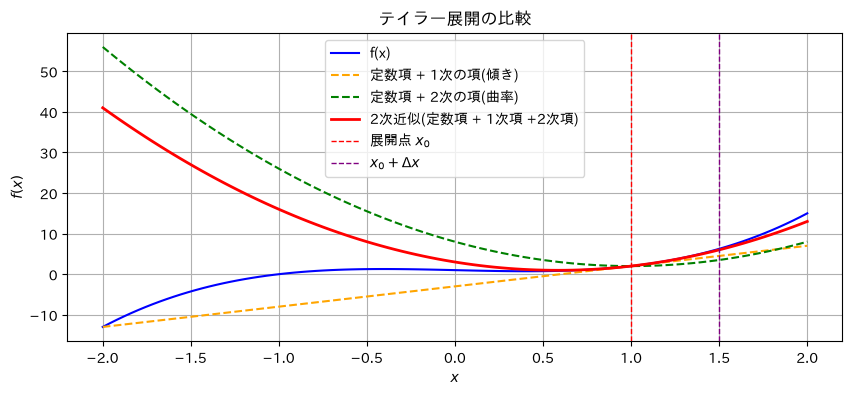

In [2]:

f = lambda x : 2*x**3 - x + 1
df = lambda x : 6*x**2 - 1
ddf = lambda x : 12*x

x_windw = np.linspace(-2, 2, 100)

x0 = 1 # 展開点
dx = 0.5 # 展開点からの距離
delta_x = x_windw - x0 # 展開点からの距離(窓枠全体)

f_data = f(x_windw)
taylor_factor_1 = df(x0)*delta_x
taylor_factor_2 = 0.5*ddf(x0)*delta_x**2

plt.figure(figsize=(10, 4))
plt.plot(x_windw, f_data, label='f(x)', color='blue')
plt.plot(x_windw, f(x0) + taylor_factor_1, label='定数項 + 1次の項(傾き)', color='orange', lw=1.5, linestyle='--')
plt.plot(x_windw, f(x0) + taylor_factor_2, label='定数項 + 2次の項(曲率)', color='green', lw=1.5, linestyle='--')
plt.plot(x_windw, f(x0) + taylor_factor_1 + taylor_factor_2 , label='2次近似(定数項 + 1次項 +2次項)', color='red', lw=2)
plt.axvline(x=x0, color='red', linestyle='--', label='展開点 $x_0$', lw=1)
plt.axvline(x=x0+dx, color='purple', linestyle='--', label='$x_0+\\Delta x$', lw=1)
plt.title('テイラー展開の比較')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid()
plt.show()


図より、テイラー展開の1次の項 ($d \ f / d x$) は直線であり、展開点 $x_0$における傾きであり、$x_0$で関数値がどの方向にどれだけ変化するかを表す。<br>
テイラー展開の2次の項 ($d^2 \ f / d \ x^2$) は放物線であり、展開点 $x_0$における曲率であり、1次近似では表現できない関数の曲がり具合を近似する。

展開点である$f(x_0)$に1次の項と2次の項を加えた値を加えると、次式で芦原される2次近似が得られる。

$$
f(x_0) + \left. \frac{d \ f}{ d x} \right|_{x=x_0} \Delta x + \left. \frac{1}{2} \frac{d^2 f}{d x^2} \right|_{x=x_0} \Delta x^2
$$

この2次近似は、展開点 $x_0$ の近傍では元の関数 $f(x)$ をよく近似している。 

## 2変数のテイラー展開

$関数f(x,y)$の$(x+\Delta x, y+ \Delta y)$ での値は、以下の式により近似できる。

$$
\begin{aligned}
f(x+\Delta x, y + \Delta y) =& f(x, y) + \frac{\partial f(x,y)}{\partial x} \Delta x + \frac{\partial f(x,y)}{\partial y} \Delta y \\ &+ \frac{1}{2} \frac{\partial ^2 f(x,y)}{\partial x^2} \Delta x^2 + \frac{1}{2} \frac{\partial ^2 f(x,y)}{\partial x \ \partial y } \Delta x \Delta y + \frac{1}{2} \frac{\partial ^2 f(x,y)}{\partial y \ \partial x} \Delta y \Delta x + \frac{1}{2} \frac{\partial ^2 f(x,y)}{\partial y^2} \Delta y^2 + \cdots
\end{aligned}
$$

ここでベクトルとベクトルの内積を $< , >$ で表す。例えば、$A = [a_1,a_2]^T, B=[b_1,b_2]^T$ とすると、$<A,B> = a_1 \ b_1 + a_2 \ b_2$となる。<br>
2次の項は一見すると項数が多く複雑である。ここでは、後で導入するヘッセ行列との対応を分かり易くするため、内積表記を使って上式を整理していく。<br>
また、$f(x,y)$を単に$f$として表記し、1階偏微分を $f_x =\partial f / \partial x$、 2階偏微分を $f_{xy} = \partial^2 f / (\partial x \ \partial y)$ のように表す。

$\Delta h = [\Delta x, \Delta y]^T$とすると、上式の1階偏微分の項は次のようにまとまる。

$$
\bigg<\begin{bmatrix} f_x \\ f_y \end{bmatrix} \ , \  \Delta h \bigg>
$$

2階偏微分は次のようにまとめることが出来る。

$$
\begin{aligned}
&\frac{1}{2} \left\{ \bigg< \begin{bmatrix}  f_{xx} \Delta x \ \\ x f_{xy} \Delta x \ \end{bmatrix} , \Delta h \bigg>  + \bigg< \begin{bmatrix} f_{yx} \Delta y  \\ f_{yy} \Delta y  \end{bmatrix} , \Delta h \bigg>\right\} \\
\end{aligned}
$$

内積の加法性 ($<a,c> + <b,c> = <a+b, c>)$ より

$$
\begin{aligned}
& = \frac{1}{2} \left\{ \bigg< \begin{bmatrix}  f_{xx} \Delta x \ \\ f_{xy} \Delta x\ \end{bmatrix}  + \begin{bmatrix} f_{yx} \Delta y  \\ f_{yy} \Delta y  \end{bmatrix} , \Delta h \bigg>\right\} \\
\end{aligned}
$$

内積の前の部分を行列とベクトルの積の形にまとめると、以下の式になる。

$$
\begin{aligned}
= &\frac{1}{2} \left\{ \Bigg<  \   \begin{bmatrix} \ f_{xx} \ \Delta x + f_{yx} \ \Delta y \\ f_{xy} \ \Delta x + f_{yy} \ \Delta y \end{bmatrix}  , \Delta h \  \Bigg> \right\} \\
= &\frac{1}{2} \left\{ \Bigg<  \begin{bmatrix} f_{xx} & f_{yx} \\  f_{xy}  & f_{yy} \end{bmatrix} \Delta h , \Delta h \  \Bigg> \right\} \\
\end{aligned}
$$

対称行列 $A$ に関する定理 $<A x, y> = <x, A^T y> $ より

$$
\begin{aligned}
= \frac{1}{2} \left\{ \bigg<  \Delta h , \begin{bmatrix} f_{xx} & f_{xy} \\ f_{yx} &f_{yy} \end{bmatrix} \Delta h \  \bigg> \right\} \\
\end{aligned}
$$


これらの結果を$f(x + \Delta x, y + \Delta y)$に代入する。

$$
f(x + \Delta x, y + \Delta y) = f(x,y) + \bigg <\begin{bmatrix} f_{x} \\ f_{y} \end{bmatrix} \ , \  \Delta h \bigg> + \frac{1}{2} \bigg<  \Delta h , \begin{bmatrix} f_{xx} & f_{xy} \\ f_{yx} &f_{yy} \end{bmatrix} \Delta h \  \bigg> + \cdots
$$

ここで、以下の$\nabla f$と 行列 $H$を定義する。
$$
\begin{array}{l}
\nabla f = \begin{bmatrix} f_x \\ f_y \end{bmatrix} \\
H = \begin{bmatrix}
f_{xx} & f_{xy} \\  f_{yx} & f_{yy} \end{bmatrix}
\end{array}
$$

また、内積 $<a,b>$ は $a^T b$ とも記述できるので、2変数の近似式は以下のように記述できる。

$$
f(x + \Delta x, y + \Delta y) = f(x,y) + \nabla f^T  \Delta h  + \frac{1}{2} \left\{ \Delta h^T H \Delta h  \right\} + \cdots
$$

下記の1変数の場合の近似式と比較すると、$\nabla f$が傾きで、$H$が曲率に相当する。<br>

$\nabla f$を勾配と呼び、その点における1次変化を表す。<br>
1変数の場合 $df/dx$ に対応する。<br>
$\nabla f$はある点 ($x_0, y_0$) における関数の傾きを表している。<br>

一方、$H$をヘッセ行列(ヘシアン)と呼び、その点における2次変化を表す。<br>
1変数の場合 $d^2 f / dx^2$ に対応する。<br>
ヘッセ行列 $H$ は $z = f(x,y)$ という曲面の、点($x_0, y_0$)における曲がり方を表している。

$$
f(x + \Delta x) =  f(x) + \frac{d \ f(x)}{d \ x} \Delta x + \frac{1}{2}\frac{d^2 \ f(x)}{d \ x^2} \Delta x^2 + \cdots
$$

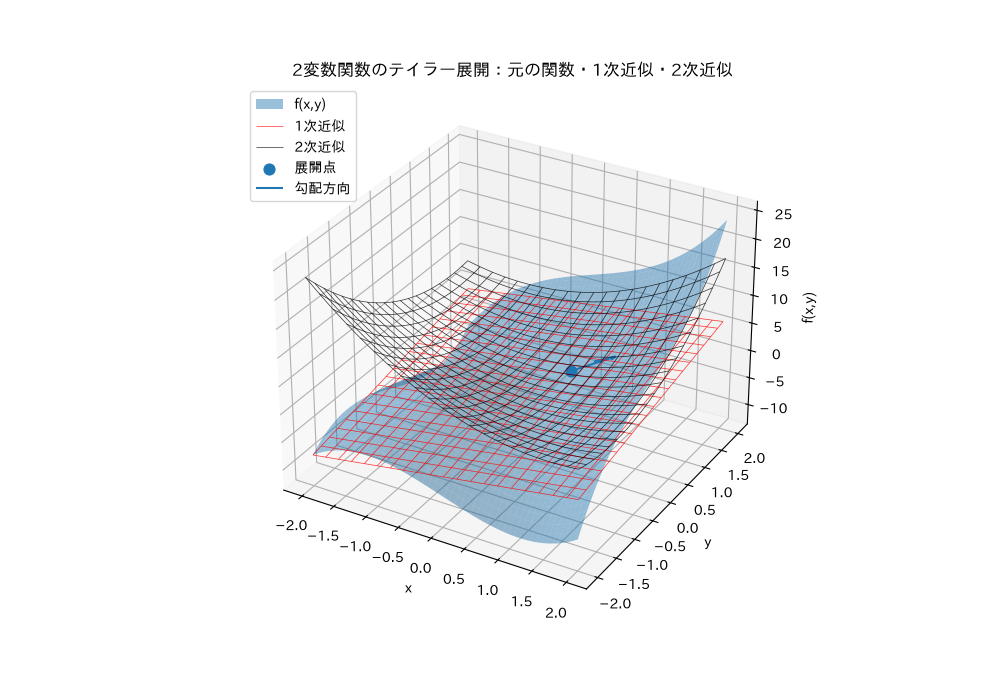

展開点: (0.5, 0.5)
f0 = 0.75
grad = [1.75 1.75]
H =
[[3. 2.]
 [2. 3.]]


In [15]:

%matplotlib widget

f = lambda x,y : x**3 + 2 * x * y + y**3
f_x = lambda x,y : 3*x**2 + 2*y
f_y = lambda x,y : 2*x + 3*y**2
f_xx = lambda x,y : 6*x
f_yy = lambda x,y : 6*y
f_xy = lambda x,y : 2
f_yx = lambda x,y : 2

x_window = np.linspace(-2, 2, 100)
y_window = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_window, y_window)

# 展開点
x0 = 0.5
y0 = 0.5

dx = X - x0
dy = Y - y0

# 元の関数
Z = f(X, Y)

# 展開点での値
f0 = f(x0, y0)

# 勾配
nabla = np.array([
    f_x(x0, y0),
    f_y(x0, y0)
])

# ヘッセ行列
H = np.array([
    [f_xx(x0, y0), f_xy(x0, y0)],
    [f_yx(x0, y0), f_yy(x0, y0)]
])

# 1次近似：接平面
Z_taylor_1 = f0 + nabla[0] * dx + nabla[1] * dy

# 2次近似：接平面 + ヘッセ行列による曲率
Z_taylor_2 = (
    f0
    + nabla[0] * dx
    + nabla[1] * dy
    + 0.5 * (
        H[0,0] * dx**2
        + H[0,1] * dx * dy
        + H[1,0] * dy * dx
        + H[1,1] * dy**2
    )
)


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 元の関数
ax.plot_surface(X, Y, Z, alpha=0.45, linewidth=0, label='f(x,y)')

# 1次近似
ax.plot_wireframe(X, Y, Z_taylor_1,
                  rstride=5,
                  cstride=5,
                  alpha=0.8, 
                  linewidth=0.5, 
                  color="red", 
                  label='1次近似')

# 2次近似
ax.plot_wireframe(X, Y, Z_taylor_2,
                  rstride=5,
                  cstride=5,
                  alpha=0.8,
                  linewidth=0.5,
                  color="black",
                  label='2次近似')

# 展開点
ax.scatter(x0, y0, f0, s=60)

# 勾配方向をxy平面上に描く
scale = 0.25
ax.quiver(
    x0, y0, f0,
    scale * nabla[0],
    scale * nabla[1],
    scale * (nabla[0]**2 + nabla[1]**2),
    length=1.0,
    normalize=False
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")
ax.set_title("2変数関数のテイラー展開：元の関数・1次近似・2次近似")
ax.legend(['f(x,y)', '1次近似', '2次近似', '展開点', '勾配方向'], loc='upper left')

plt.show()

print("展開点:", (x0, y0))
print("f0 =", f0)
print("grad =", nabla)
print("H =")
print(H)


In [4]:
## 1変数のテイラー展開